In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')

In [5]:
Cadv_int = data_Cadv.Ah0.integrate("time",datetime_unit="s")

In [17]:
# spatially filter dissipation; running mean, binsize = N
N = 50
Cadv_int_filter = Cadv_int.data.copy()
for i in range(len(data.x)):
    Cadv_int_filter[i,:] = np.convolve(Cadv_int_filter[i,:], np.ones(N)/N, 'same')
for j in range(len(data.y)):
    Cadv_int_filter[:,j] = np.convolve(Cadv_int_filter[:,j], np.ones(N)/N, 'same')

# Island center & Shoaling depth

In [6]:
lambdaM2=70.1e3
l_sponge = 20e3
slope = 0.05
D0 = 600
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2
He = 313.1
width_he2 = 26000
width_top = width_he2 - 2*(He/2)/slope

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [7]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

In [8]:
x_top = x_c+width_top/2
x_bottom = x_top + D0/slope
x_shoal = x_top + depth_shoal/slope

# Scale time

In [9]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

# Section domain into circles & quadrants

In [10]:
data_c = xr.open_dataset('../results_intermediate/dis_theta_c.nc')
dis_c = data_c.dis_c.data
theta_c = data_c.theta_c.data

In [11]:
dis_top = np.mean(dis_c[np.where((data_.depth>=depth_top+.1) & (data_.depth.data<=depth_top+2))])
dis_shoal = np.mean(dis_c[np.where((data_.depth>=depth_shoal-1) & (data_.depth.data<=depth_shoal+1))])
dis_bottom = np.mean(dis_c[np.where((data_.depth>=depth_bottom-1) & (data_.depth.data<depth_bottom))])
quadrants_info = {
    "r_quad": np.array([dis_top, dis_shoal,dis_bottom]),
    "quadrants": ['east', 'north', 'west', 'south'],
    "theta_edge":np.array([-45, 45, 135, -135]),
    "theta_quad": [[-45, 45], [45, 135], [135, -135], [-135, -45]], 
    "grid_number": 500,
            }

In [12]:
# mask out data outside of the inner ring
mask_ring_inner = (dis_c>=quadrants_info["r_quad"][0]) & (dis_c<quadrants_info["r_quad"][1])
mask_ring_inner_east = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_inner_north = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_inner_west = mask_ring_inner & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_inner_south = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# mask out data outside of the outer ring
mask_ring_outer = (dis_c>=quadrants_info["r_quad"][1]) & (dis_c<quadrants_info["r_quad"][-1])
mask_ring_outer_east = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_outer_north = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_outer_west = mask_ring_outer & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_outer_south = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# Area-integrated, time-integrated energy budget

## energy flux divergence

In [13]:
data_bc = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bc.nc')
data_bt = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bt.nc')
div_Fprime = data_bc.div_Fprime1[-1,:,:].data+data_bc.div_Fprime2[-1,:,:].data+data_bc.div_Fprime3[-1,:,:].data+data_bc.div_Fprime4[-1,:,:].data+data_bc.div_Fprime5[-1,:,:].data
div_F0 = data_bt.div_F01[-1,:,:].data+data_bt.div_F02[-1,:,:].data+data_bt.div_F03[-1,:,:].data+data_bt.div_F04[-1,:,:].data
del data_bc, data_bt

In [14]:
data["div_Fprime"]=(['x', 'y'],  div_Fprime)
data["div_F0"]=(['x', 'y'],  div_F0)

## dissipation

In [15]:
dissip0 = data.dissip0[-1,:,:]
dissip_prime = data.dissip_prime[-1,:,:]

# spatially filter dissipation; running mean, binsize = N
N = 10
dissip_prime_filter = dissip_prime.data.copy()
dissip_0_filter = dissip0.data.copy()
for i in range(len(data.x)):
    dissip_prime_filter[i,:] = np.convolve(dissip_prime_filter[i,:], np.ones(N)/N, 'same')
    dissip_0_filter[i,:] = np.convolve(dissip_0_filter[i,:], np.ones(N)/N, 'same')
for j in range(len(data.y)):
    dissip_prime_filter[:,j] = np.convolve(dissip_prime_filter[:,j], np.ones(N)/N, 'same')
    dissip_0_filter[:,j] = np.convolve(dissip_0_filter[:,j], np.ones(N)/N, 'same')

In [18]:
data["dissip_prime_filter"]=(['x', 'y'],  dissip_prime_filter-Cadv_int_filter.data)
data["dissip_0_filter"]=(['x', 'y'],  dissip_0_filter+Cadv_int_filter.data)

## Conversion

In [19]:
C_int = data_.C_int

# spatially filter dissipation; running mean, binsize = N
N = 10
C_int_filter = C_int[-1,:,:].data.copy()
for i in range(len(data.x)):
    C_int_filter[i,:] = np.convolve(C_int_filter[i,:], np.ones(N)/N, 'same')
for j in range(len(data.y)):
    C_int_filter[:,j] = np.convolve(C_int_filter[:,j], np.ones(N)/N, 'same')

In [20]:
data["C_int_filter"]=(['x', 'y'],  C_int_filter+Cadv_int_filter.data)

## Area integration

In [21]:
# mask out data outside of the rings, inner & outer 
div_Fprime_int_ring = np.zeros((4, 2))
div_F0_int_ring = np.zeros((4, 2))
dissp_prime_int_ring = np.zeros((4, 2))
dissp_0_int_ring = np.zeros((4, 2))
D_prime_int_ring = np.zeros((4, 2))
D_0_int_ring = np.zeros((4, 2))
C_int_ring = np.zeros((4, 2))

for i in range(4):
    var = data["div_Fprime"].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    div_Fprime_int_ring[i,0] = var_.integrate('y')
    var = data["div_Fprime"].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    div_Fprime_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    var = data["div_F0"].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    div_F0_int_ring[i,0] = var_.integrate('y')
    var = data["div_F0"].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    div_F0_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    # var = data["dissip_prime_filter"].copy()-Cadv_int_filter.data
    var = data["dissip_prime"][-1,:,:].copy()-Cadv_int.data
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dissp_prime_int_ring[i,0] = var_.integrate('y')
    # var = data["dissip_prime_filter"].copy()-Cadv_int_filter.data
    var = data["dissip_prime"][-1,:,:].copy()-Cadv_int.data
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dissp_prime_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    # var = data["dissip_0_filter"].copy()+Cadv_int_filter.data
    var = data["dissip0"][-1,:,:].copy()+Cadv_int.data
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dissp_0_int_ring[i,0] = var_.integrate('y')
    # var = data["dissip_0_filter"].copy()
    var = data["dissip0"][-1,:,:].copy()+Cadv_int.data
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dissp_0_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    var = data_["D_prime"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    D_prime_int_ring[i,0] = var_.integrate('y')
    var = data_["D_prime"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    D_prime_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    var = data_["D0"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    D_0_int_ring[i,0] = var_.integrate('y')
    var = data_["D0"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    D_0_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    # var = data["C_int_filter"].copy()+Cadv_int_filter.data
    var = data_["C_int"][-1,:,:].copy()+Cadv_int.data
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    C_int_ring[i,0] = var_.integrate('y')
    # var = data["C_int_filter"].copy()
    var = data_["C_int"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    C_int_ring[i,1] = var_.integrate('y')


In [22]:
dEp0_int_ring = np.zeros((4, 2))
dEk0_int_ring = np.zeros((4, 2))
dEp_prime_int_ring = np.zeros((4, 2))
dEk_prime_int_ring = np.zeros((4, 2))

for i in range(4):
    var = data_["dEp0"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dEp0_int_ring[i,0] = var_.integrate('y')
    var = data_["dEp0"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dEp0_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    var = data_["dEk0"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dEk0_int_ring[i,0] = var_.integrate('y')
    var = data_["dEk0"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dEk0_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    var = data_["dEp_prime"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dEp_prime_int_ring[i,0] = var_.integrate('y')
    var = data_["dEp_prime"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dEp_prime_int_ring[i,1] = var_.integrate('y')


for i in range(4):
    var = data_["dEk_prime"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dEk_prime_int_ring[i,0] = var_.integrate('y')
    var = data_["dEk_prime"][-1,:,:].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    dEk_prime_int_ring[i,1] = var_.integrate('y')

In [23]:
# areas
data["ones"]=(['x', 'y'],  np.zeros(data_.depth.data.shape)+1)
area_ring = np.zeros((4, 2))
for i in range(4):
    var = data["ones"].copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    area_ring[i,0] = var_.integrate('y')
    var = data["ones"].copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    area_ring[i,1] = var_.integrate('y')

In [24]:
# https://stackoverflow.com/questions/5328128/scipy-interpolation-of-large-matrix

def interp2d_nearest(X, Y, Z, x, y, spn=3, method='linear'):
    from scipy import interpolate
    xs,ys = map(np.array,(x,y))
    z = np.zeros(xs.shape)
    for i,(x,y) in enumerate(zip(xs,ys)):
        # get the indices of the nearest x,y
        xi = np.argmin(np.abs(X[0,:]-x))
        yi = np.argmin(np.abs(Y[:,0]-y))
        xlo = max(xi-spn, 0)
        ylo = max(yi-spn, 0)
        xhi = min(xi+spn, X[0,:].size)
        yhi = min(yi+spn, Y[:,0].size)
        # make slices of X,Y,Z that are only a few items wide
        nX = X.T[xlo:xhi, ylo:yhi]
        nY = Y.T[xlo:xhi, ylo:yhi]
        nZ = Z[xlo:xhi, ylo:yhi]
        intp = interpolate.interp2d(nX, nY, nZ, method)
        z[i] = intp(x,y)[0]
    return z


# Fluxes on edges

In [25]:
[xv, yv] = np.meshgrid(data.x.data,data.y.data)
# del data, data_

In [26]:
data_bc_fx = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bc_flux_x.nc')
data_bc_fy = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bc_flux_y.nc')

Fx_prime_int = data_bc_fx.Fx_prime1_int[-1,:,:].data+data_bc_fx.Fx_prime2_int[-1,:,:].data+data_bc_fx.Fx_prime3_int[-1,:,:].data+data_bc_fx.Fx_prime4_int[-1,:,:].data+data_bc_fx.Fx_prime5_int[-1,:,:].data
Fy_prime_int = data_bc_fy.Fy_prime1_int[-1,:,:].data+data_bc_fy.Fy_prime2_int[-1,:,:].data+data_bc_fy.Fy_prime3_int[-1,:,:].data+data_bc_fy.Fy_prime4_int[-1,:,:].data+data_bc_fy.Fy_prime5_int[-1,:,:].data
del data_bc_fx, data_bc_fy

In [27]:
data_bt_fx = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bt_flux_x.nc')
data_bt_fy = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bt_flux_y.nc')

Fx_0_int = data_bt_fx.Fx_01_int[-1,:,:].data+data_bt_fx.Fx_02_int[-1,:,:].data+data_bt_fx.Fx_03_int[-1,:,:].data+data_bt_fx.Fx_04_int[-1,:,:].data
Fy_0_int = data_bt_fy.Fy_01_int[-1,:,:].data+data_bt_fy.Fy_02_int[-1,:,:].data+data_bt_fy.Fy_03_int[-1,:,:].data+data_bt_fy.Fy_04_int[-1,:,:].data
del data_bt_fx, data_bt_fy

In [28]:
def cart_to_cyl(u,v,theta):
    """ this function transforms a cartesian vector u,v to cylindrical coordinates u_r, u_theta, with angle theta (rad)
    """
    u_r = u * np.cos(theta) + v * np.sin(theta)
    u_theta = -u * np.sin(theta) + v * np.cos(theta)
    return u_r, u_theta

In [29]:
# transform to cylindrical coordinates
F_r_prime_int, F_theta_prime_int = cart_to_cyl(Fx_prime_int, Fy_prime_int, theta_c)
F_r_0_int, F_theta_0_int = cart_to_cyl(Fx_0_int, Fy_0_int, theta_c)

/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=10,7 m=36 fp=11412287.666406 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=10,7 m=36 fp=162280032.734036 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already

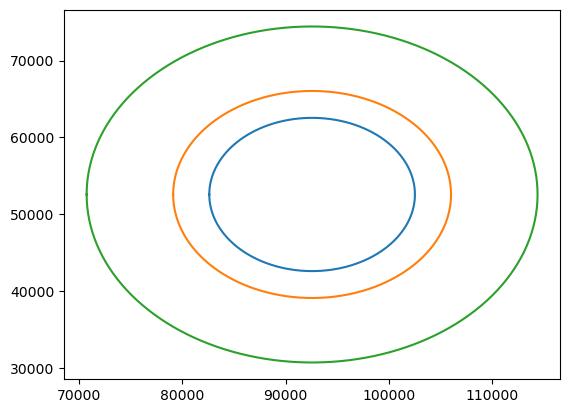

In [30]:
# interp F_prime onto rings and quadrants
x_circles = np.zeros((quadrants_info["grid_number"], len(quadrants_info["r_quad"])))
y_circles = np.zeros((quadrants_info["grid_number"], len(quadrants_info["r_quad"])))
F_r_prime_int_ring = np.zeros((quadrants_info["grid_number"], len(quadrants_info["r_quad"])))
F_theta_prime_int_ring = np.zeros((quadrants_info["grid_number"], len(quadrants_info["r_quad"])))
F_r_0_int_ring = np.zeros((quadrants_info["grid_number"], len(quadrants_info["r_quad"])))
F_theta_0_int_ring = np.zeros((quadrants_info["grid_number"], len(quadrants_info["r_quad"])))
# circles - small to big
theta_circles = np.linspace(-np.pi,np.pi,quadrants_info["grid_number"])
for i in range(len(quadrants_info["r_quad"])):
    x_circles[:,i] = quadrants_info["r_quad"][i]*np.cos(theta_circles) + x_c
    y_circles[:,i] = quadrants_info["r_quad"][i]*np.sin(theta_circles) + y_c
    plt.plot(x_circles[:,i],y_circles[:,i])
    F_r_prime_int_ring[:,i] = interp2d_nearest(xv, yv, F_r_prime_int, x_circles[:,i], y_circles[:,i], spn=3, method='linear')
    F_theta_prime_int_ring[:,i] = interp2d_nearest(xv, yv, F_theta_prime_int, x_circles[:,i], y_circles[:,i], spn=3, method='linear')
    F_r_0_int_ring[:,i] = interp2d_nearest(xv, yv, F_r_0_int, x_circles[:,i], y_circles[:,i], spn=3, method='linear')
    F_theta_0_int_ring[:,i] = interp2d_nearest(xv, yv, F_theta_0_int, x_circles[:,i], y_circles[:,i], spn=3, method='linear')

/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=10,7 m=36 fp=355712528329.757324 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=10,7 m=36 fp=221030022027.497803 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients 

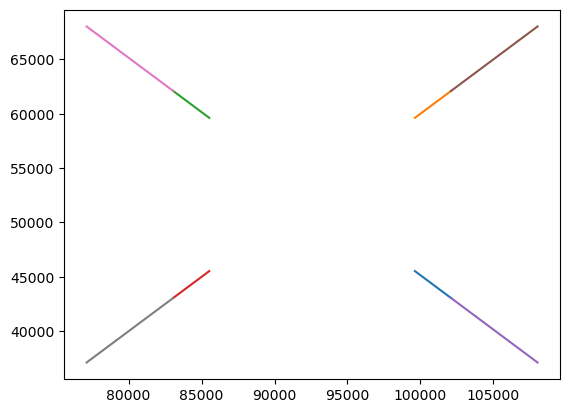

In [31]:
# interp F_prime onto rings and quadrants
x_edges = np.zeros((quadrants_info["grid_number"], len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
y_edges = np.zeros((quadrants_info["grid_number"], len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
F_r_prime_int_edges = np.zeros((quadrants_info["grid_number"], len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
F_theta_prime_int_edges = np.zeros((quadrants_info["grid_number"], len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
F_r_0_int_edges = np.zeros((quadrants_info["grid_number"], len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
F_theta_0_int_edges = np.zeros((quadrants_info["grid_number"], len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
# edges
for ii in range(len(quadrants_info["r_quad"])-1):
    r_edges = np.linspace(quadrants_info["r_quad"][ii],quadrants_info["r_quad"][ii+1],quadrants_info["grid_number"])
    for i in range(len(quadrants_info["quadrants"])):
        x_edges[:,i,ii] = r_edges*np.cos(np.pi*quadrants_info["theta_edge"][i]/180) + x_c
        y_edges[:,i,ii] = r_edges*np.sin(np.pi*quadrants_info["theta_edge"][i]/180) + y_c
        plt.plot(x_edges[:,i,ii],y_edges[:,i,ii])
        F_r_prime_int_edges[:,i,ii] = interp2d_nearest(xv, yv, F_r_prime_int, x_edges[:,i,ii], y_edges[:,i,ii], spn=3, method='linear')
        F_theta_prime_int_edges[:,i,ii] = interp2d_nearest(xv, yv, F_theta_prime_int, x_edges[:,i,ii], y_edges[:,i,ii], spn=3, method='linear')
        F_r_0_int_edges[:,i,ii] = interp2d_nearest(xv, yv, F_r_0_int, x_edges[:,i,ii], y_edges[:,i,ii], spn=3, method='linear')
        F_theta_0_int_edges[:,i,ii] = interp2d_nearest(xv, yv, F_theta_0_int, x_edges[:,i,ii], y_edges[:,i,ii], spn=3, method='linear')

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_38250/1278023838.py:5: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  cb1 = plt.colorbar(im1, location='right', extend='both')


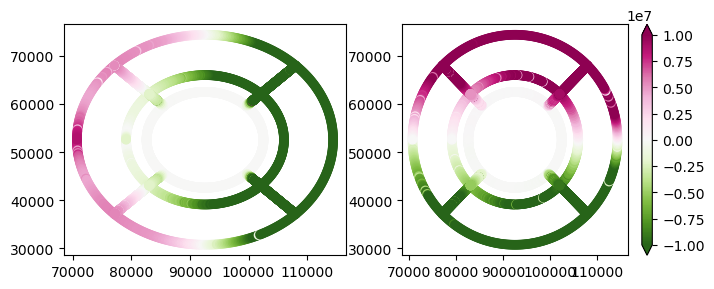

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

im1 = ax[0].scatter(x_circles, y_circles, c=F_r_prime_int_ring, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
ax[0].scatter(x_edges, y_edges, c=F_r_prime_int_edges, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
cb1 = plt.colorbar(im1, location='right', extend='both')

ax[1].scatter(x_circles, y_circles, c=F_theta_prime_int_ring, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
ax[1].scatter(x_edges, y_edges, c=F_theta_prime_int_edges, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_38250/1278023838.py:5: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  cb1 = plt.colorbar(im1, location='right', extend='both')


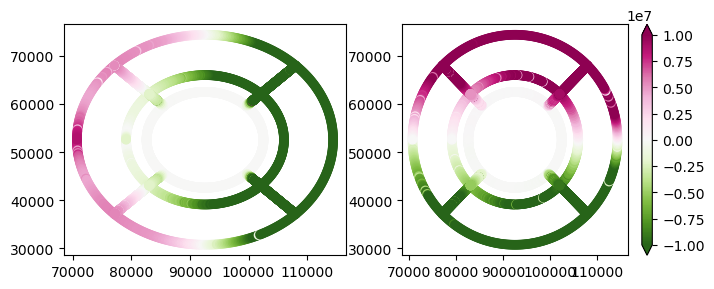

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

im1 = ax[0].scatter(x_circles, y_circles, c=F_r_prime_int_ring, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
ax[0].scatter(x_edges, y_edges, c=F_r_prime_int_edges, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
cb1 = plt.colorbar(im1, location='right', extend='both')

ax[1].scatter(x_circles, y_circles, c=F_theta_prime_int_ring, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
ax[1].scatter(x_edges, y_edges, c=F_theta_prime_int_edges, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)

In [34]:
# mask out data outside of the inner ring
mask_circles_east = (theta_circles>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_circles<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_circles_north = (theta_circles>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_circles<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_circles_west = (theta_circles>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_circles<quadrants_info["theta_quad"][2][1]*np.pi/180)
mask_circles_south = (theta_circles>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_circles<quadrants_info["theta_quad"][-1][1]*np.pi/180)

In [35]:
dis_circles = np.zeros(x_circles.shape)
dis_edges = np.zeros(x_edges.shape)
for i in range(len(quadrants_info["r_quad"])):
    dis_circles[:,i] = np.hstack([0, np.cumsum(np.sqrt((x_circles[1::,i]-x_circles[0:-1,i])**2+(y_circles[1::,i]-y_circles[0:-1,i])**2))])
for ii in range(len(quadrants_info["r_quad"])-1):
    for i in range(len(quadrants_info["quadrants"])):
        dis_edges[:,i,ii] = np.hstack([0, np.cumsum(np.sqrt((x_edges[1::,i,ii]-x_edges[0:-1,i,ii])**2+(y_edges[1::,i,ii]-y_edges[0:-1,i,ii])**2))])

In [36]:
F_r_prime_int_ring_int = np.zeros((len(quadrants_info["r_quad"]), 4))
F_theta_prime_int_ring_int = np.zeros((len(quadrants_info["r_quad"]), 4))
F_r_0_int_ring_int = np.zeros((len(quadrants_info["r_quad"]), 4))
F_theta_0_int_ring_int = np.zeros((len(quadrants_info["r_quad"]), 4))
for i in range(len(quadrants_info["r_quad"])):
    for count in range(4):
        var_ = F_r_prime_int_ring[:,i].copy()
        mask=eval(f'mask_circles_{quadrants_info["quadrants"][count]}.copy()')
        var_[~mask] = 0
        F_r_prime_int_ring_int[i,count] = np.trapz(var_, dis_circles[:,i])
        var_ = F_theta_prime_int_ring[:,i].copy()
        mask=eval(f'mask_circles_{quadrants_info["quadrants"][count]}.copy()')
        var_[~mask] = 0
        F_theta_prime_int_ring_int[i,count] = np.trapz(var_, dis_circles[:,i])
        var_ = F_r_0_int_ring[:,i].copy()
        mask=eval(f'mask_circles_{quadrants_info["quadrants"][count]}.copy()')
        var_[~mask] = 0
        F_r_0_int_ring_int[i,count] = np.trapz(var_, dis_circles[:,i])
        var_ = F_theta_0_int_ring[:,i].copy()
        mask=eval(f'mask_circles_{quadrants_info["quadrants"][count]}.copy()')
        var_[~mask] = 0
        F_theta_0_int_ring_int[i,count] = np.trapz(var_, dis_circles[:,i])

In [37]:
F_r_prime_int_edges_int = np.zeros((len(quadrants_info["r_quad"])-1, 4))
F_theta_prime_int_edges_int = np.zeros((len(quadrants_info["r_quad"])-1, 4))
F_r_0_int_edges_int = np.zeros((len(quadrants_info["r_quad"])-1, 4))
F_theta_0_int_edges_int = np.zeros((len(quadrants_info["r_quad"])-1, 4))
for i in range(len(quadrants_info["r_quad"])-1):
    for count in range(4):
        var_ = F_r_prime_int_edges[:,count,i].copy()
        F_r_prime_int_edges_int[i,count] = np.trapz(var_, dis_edges[:,i,ii])
        var_ = F_theta_prime_int_edges[:,count,i].copy()
        F_theta_prime_int_edges_int[i,count] = np.trapz(var_, dis_edges[:,i,ii])
        var_ = F_r_0_int_edges[:,count,i].copy()
        F_r_0_int_edges_int[i,count] = np.trapz(var_, dis_edges[:,i,ii])
        var_ = F_theta_0_int_edges[:,count,i].copy()
        F_theta_0_int_edges_int[i,count] = np.trapz(var_, dis_edges[:,i,ii])

# Plot

In [ ]:
bar_colors_pos = ['tab:gray', 'tab:blue', 'tab:pink', 'tab:brown']
bar_colors_neg = ['tab:gray', 'tab:blue', 'tab:green', 'tab:brown']
bar_labels = [r"$\nabla\cdot$F'", r"$\nabla\cdot$F$_0$", r"C", r"$\epsilon$+D"]
quadrant_names = ['east','north','west','south']

for idx_quad in range(4):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4,4))
    if C_int_ring[idx_quad,0]>0:
        ax.bar(np.arange(4)/4,[div_Fprime_int_ring[idx_quad,0]*1e-9, div_F0_int_ring[idx_quad,0]*1e-9, C_int_ring[idx_quad,0]*1e-9, (dissp_prime_int_ring[idx_quad,0]+D_prime_int_ring[idx_quad,0]+dissp_0_int_ring[idx_quad,0]+D_0_int_ring[idx_quad,0])*1e-9], color=bar_colors_pos, edgecolor='k', hatch='///', width=.1, align='center')
    else:    
        ax.bar(np.arange(4)/4,[div_Fprime_int_ring[idx_quad,0]*1e-9, div_F0_int_ring[idx_quad,0]*1e-9, C_int_ring[idx_quad,0]*1e-9, (dissp_prime_int_ring[idx_quad,0]+D_prime_int_ring[idx_quad,0]+dissp_0_int_ring[idx_quad,0]+D_0_int_ring[idx_quad,0])*1e-9], color=bar_colors_neg, edgecolor='k', hatch='///', width=.1, align='center')
    if C_int_ring[idx_quad,1]>0:
        ax.bar(np.arange(4)/4+.1,[div_Fprime_int_ring[idx_quad,1]*1e-9, div_F0_int_ring[idx_quad,1]*1e-9, C_int_ring[idx_quad,1]*1e-9, (dissp_prime_int_ring[idx_quad,1]+D_prime_int_ring[idx_quad,1]+dissp_0_int_ring[idx_quad,1]+D_0_int_ring[idx_quad,1])*1e-9], color=bar_colors_pos, edgecolor='k', width=.1, align='center')
    else:
        ax.bar(np.arange(4)/4+.1,[div_Fprime_int_ring[idx_quad,1]*1e-9, div_F0_int_ring[idx_quad,1]*1e-9, C_int_ring[idx_quad,1]*1e-9, (dissp_prime_int_ring[idx_quad,1]+D_prime_int_ring[idx_quad,1]+dissp_0_int_ring[idx_quad,1]+D_0_int_ring[idx_quad,1])*1e-9], color=bar_colors_neg, edgecolor='k', width=.1, align='center')        
    var_0 = np.round([div_Fprime_int_ring[idx_quad,0]*1e-9, div_F0_int_ring[idx_quad,0]*1e-9, C_int_ring[idx_quad,0]*1e-9, (dissp_prime_int_ring[idx_quad,0]+D_prime_int_ring[idx_quad,0]+dissp_0_int_ring[idx_quad,0]+D_0_int_ring[idx_quad,0])*1e-9]).astype('int')
    var_1 = np.round([div_Fprime_int_ring[idx_quad,1]*1e-9, div_F0_int_ring[idx_quad,1]*1e-9, C_int_ring[idx_quad,1]*1e-9, (dissp_prime_int_ring[idx_quad,1]+D_prime_int_ring[idx_quad,1]+dissp_0_int_ring[idx_quad,1]+D_0_int_ring[idx_quad,1])*1e-9]).astype('int')
    for i in range(len(var_0)):
        if i==0:
            if var_0[i]>0:
                ax.text(i/4-.09, var_0[i]+20, str(var_0[i]), color='black', fontweight='bold', fontsize=14, ha='left', va='center')
            else:
                ax.text(i/4-.09, 20, str(var_0[i]), color='black', fontweight='bold', fontsize=14, ha='left', va='center')    
        else:
            if var_0[i]>0:
                ax.text(i/4-.06, var_0[i]+20, str(var_0[i]), color='black', fontweight='bold', fontsize=14, ha='left', va='center')
            else:
                ax.text(i/4-.06, 20, str(var_0[i]), color='black', fontweight='bold', fontsize=14, ha='left', va='center')                
    for i in range(len(var_1)):
        if var_1[i]>0:
            ax.text(.1+i/4-.04, var_1[i]+20, str(var_1[i]), color='black', fontweight='bold', fontsize=14, ha='left', va='center')
        else:
            ax.text(.1+i/4-.04, 20, str(var_1[i]), color='black', fontweight='bold', fontsize=14, ha='left', va='center')    
    # for i in range(len(var_1)):
    #     ax.text(.1+i/4-.06, -300, bar_labels[i], color='black', fontweight='bold', fontsize=14, ha='left', va='center') 
            
    ax.grid(False)
    ax.set_xlim([-.2,1])
    ax.set_ylim([-500,500])
    ax.set_yticks(np.arange(-400,400+1,100))
    ax.set_yticklabels(['-400','', '-200','','0','','200','','400'])
    ax.tick_params(axis='y', which='major', labelsize=12)
    ax.set_ylabel(r'GJ', fontsize=14)
    ax.set_xticks(np.arange(4)/4)
    ax.set_xticklabels(bar_labels)
    ax.tick_params(axis='x', which='major', labelsize=14, rotation = 45)
    ax.set_axis_off()
    ax.set_aspect(1/800)
    
    # plt.tight_layout()
    plt.rcParams["font.family"] = "Times New Roman"
    plt.savefig(outfilepath+ f"Energy_budget_int_quadrants_summer_nof_ver{quadrant_names[idx_quad]}.png", dpi=300, transparent=True)

# energy budget in Watts/m^2

In [43]:
dissp = data.dissip0 + data.dissip_prime + data_.D0 + data_.D_prime
dissp_t = dissp.differentiate("time",datetime_unit="s")

In [45]:
data_["ones"]=(['x', 'y'],  np.ones(data_.depth.shape))

In [46]:
# mask out data outside of the rings, inner & outer 
dissp_t_int_ring = np.zeros((len(data.time), 4, 2))
areas_int_ring = np.zeros((4, 2))
volumes_int_ring = np.zeros((4, 2))
for ii in range(len(data.time)):
    for i in range(4):
        var = dissp_t[ii,:,:].copy()
        mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
        var.data[~mask_] = 0
        var_ = var.integrate('x')
        dissp_t_int_ring[ii,i,0] = var_.integrate('y')

        var = dissp_t[ii,:,:].copy()
        mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
        var.data[~mask_] = 0
        var_ = var.integrate('x')
        dissp_t_int_ring[ii,i,1] = var_.integrate('y')

for i in range(4):
    var = data_.ones.copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    areas_int_ring[i,0] = var_.integrate('y')

    var = data_.ones.copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    areas_int_ring[i,1] = var_.integrate('y')

for i in range(4):
    var = data_.depth.copy()
    mask_ = eval(f'mask_ring_inner_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    volumes_int_ring[i,0] = var_.integrate('y')

    var = data_.depth.copy()
    mask_ = eval(f'mask_ring_outer_{quadrants_info["quadrants"][i]}').copy()
    var.data[~mask_] = 0
    var_ = var.integrate('x')
    volumes_int_ring[i,1] = var_.integrate('y')


In [40]:
dissp_int = dissp_prime_int_ring+D_prime_int_ring+dissp_0_int_ring+D_0_int_ring

In [41]:
print(f"friction/total dissipation = {np.sum(D_prime_int_ring+D_0_int_ring, axis=0)/np.sum(dissp_int, axis=0)}")
print(f"inner/total dissipation = {np.sum(dissp_int, axis=0)[0]/np.sum(np.sum(dissp_int, axis=0))}")
print(f"total friction/total dissipation = {np.sum(np.sum(D_prime_int_ring+D_0_int_ring, axis=0))/np.sum(np.sum(dissp_int, axis=0))}")

friction/total dissipation = [0.1485072  0.53511532]
inner/total dissipation = 0.8538897183873793
total friction/total dissipation = 0.20499462041711616


In [47]:
T_island = dis_bottom*2/c
T_M2 = 12.42*3600
APE = 18.8e6
L_cross_slope = np.array([dis_shoal-dis_top, dis_bottom - dis_shoal])
L_cross_island = np.array([dis_shoal*2, dis_bottom*2])
areas_int_island = np.array([np.pi*dis_shoal**2, np.pi*dis_bottom**2])

print(f"Fx in Wm^-1 (averaged by T_island):{APE*2/T_island}")
print(f"Fx in Wm^-1 (averaged by T_M2):{APE*2/T_M2}")
print(f"time for wave to travel pass island in s T_island = {T_island}")
print(20*'=', ' inner circle ',20*'=')
print(f"area in m^2: {areas_int_island[0]}")
print(f"time-integrated dissipation in Jm^-2: {np.sum(dissp_int[:,0])/areas_int_island[0]}")
print(f"time-averaged dissipation rate in Wm^-2 (averaged by T_island): {np.sum(dissp_int[:,0])/areas_int_island[0]/T_island}, in Wm^-1: {np.sum(dissp_int)/areas_int_island[0]/T_island*L_cross_island[0]}")
print(f"time-averaged dissipation rate in Wm^-2 (averaged by T_M2): {np.sum(dissp_int[:,0])/areas_int_island[0]/T_M2}, in Wm^-1: {np.sum(dissp_int)/areas_int_island[0]/T_M2*L_cross_island[0]}")

print(20*'=', ' total circle',20*'=')
print(f"area in m^2: {np.sum(areas_int_island)}")
print(f"time-integrated dissipation in Jm^-2: {np.sum(dissp_int)/np.sum(areas_int_island)}")
print(f"time-averaged dissipation rate in Wm^-2 (averaged by T_island): {np.sum(dissp_int)/np.sum(areas_int_island)/T_island}, in Wm^-1: {np.sum(dissp_int)/np.sum(areas_int_island)/T_island*L_cross_island[1]}")
print(f"time-averaged dissipation rate in Wm^-2 (averaged by T_M2): {np.sum(dissp_int)/np.sum(areas_int_island)/T_M2}, in Wm^-1: {np.sum(dissp_int)/np.sum(areas_int_island)/T_M2*L_cross_island[1]}")
print(f"time-integrated conversion in Jm^-2: {np.sum(C_int_ring)/np.sum(areas_int_island)}")
print(f"time-averaged conversion rate in Wm^-2 (averaged by T_island): {np.sum(C_int_ring)/np.sum(areas_int_island)/T_island}, in Wm^-1: {np.sum(C_int_ring)/np.sum(areas_int_island)/T_island*L_cross_island[1]}")
print(f"time-averaged conversion rate in Wm^-2 (averaged by T_M2): {np.sum(C_int_ring)/np.sum(areas_int_island)/T_M2}, in Wm^-1: {np.sum(C_int_ring)/np.sum(areas_int_island)/T_M2*L_cross_island[1]}")

for idx_quad in range(4):
    print(10*'=','quadrant ',quadrants_info["quadrants"][idx_quad],10*'=','[inner   ', 'outer   ]')
    print(f"area in m^2: {areas_int_ring[idx_quad,:]}, outer area is {areas_int_ring[idx_quad,1]/areas_int_ring[idx_quad,0]} times of inner area")
    print(f"volume in m^3: {volumes_int_ring[idx_quad,:]}")
    print(f"maximum dissipation rate in Wm^-2: {dissp_t_int_ring.max(axis=0)[idx_quad,:]/areas_int_ring[idx_quad,:]}, in Wm^-1: {dissp_t_int_ring.max(axis=0)[idx_quad,:]/areas_int_ring[idx_quad,:]*L_cross_slope}")
    # print(f"median dissipation rate in Wm^-2: {np.median(dissp_t_int_ring, axis=0)[idx_quad,:]/areas_int_ring[idx_quad,:]}")
    print(f"time-integrated dissipation in Jm^-2: {dissp_int[idx_quad,:]/areas_int_ring[idx_quad,:]}")
    print(f"time-averaged dissipation rate in Wm^-2 (averaged by T_island): {dissp_int[idx_quad,:]/areas_int_ring[idx_quad,:]/T_island}, in Wm^-1: {dissp_int[idx_quad,:]/areas_int_ring[idx_quad,:]/T_island*L_cross_slope}")
    print(f"time-averaged dissipation rate in Wm^-2 (averaged by T_M2): {dissp_int[idx_quad,:]/areas_int_ring[idx_quad,:]/T_M2}, in Wm^-1: {dissp_int[idx_quad,:]/areas_int_ring[idx_quad,:]/T_M2*L_cross_slope}")
    # print(f"maximum conversion rate in Wm^-2: {C_int_ring.max(axis=0)[idx_quad,:]/areas_int_ring[idx_quad,:]}, in Wm^-1: {C_int_ring.max(axis=0)[idx_quad,:]/areas_int_ring[idx_quad,:]*L_cross_slope}")
    # print(f"minimum conversion rate in Wm^-2: {C_int_ring.min(axis=0)[idx_quad,:]/areas_int_ring[idx_quad,:]}, in Wm^-1: {C_int_ring.min(axis=0)[idx_quad,:]/areas_int_ring[idx_quad,:]*L_cross_slope}")
    print(f"time-integrated conversion in Jm^-2: {C_int_ring[idx_quad,:]/areas_int_ring[idx_quad,:]}")
    print(f"time-averaged conversion rate in Wm^-2 (averaged by T_island): {C_int_ring[idx_quad,:]/areas_int_ring[idx_quad,:]/T_island}, in Wm^-1: {C_int_ring[idx_quad,:]/areas_int_ring[idx_quad,:]/T_island*L_cross_slope}")
    print(f"time-averaged conversion rate in Wm^-2 (averaged by T_M2): {C_int_ring[idx_quad,:]/areas_int_ring[idx_quad,:]/T_M2}, in Wm^-1: {C_int_ring[idx_quad,:]/areas_int_ring[idx_quad,:]/T_M2*L_cross_slope}")


Fx in Wm^-1 (averaged by T_island):1475.3346207667016
Fx in Wm^-1 (averaged by T_M2):840.9375559134013
time for wave to travel pass island in s T_island = 25485.74368875045
====================  inner circle  ====================
area in m^2: 569950059.6683718
time-integrated dissipation in Jm^-2: 1386.1713665337834
time-averaged dissipation rate in Wm^-2 (averaged by T_island): 0.05439006934475478, in Wm^-1: 1715.8972937336325
time-averaged dissipation rate in Wm^-2 (averaged by T_M2): 0.031002222368352643, in Wm^-1: 978.0577613239375
====================  total circle ====================
area in m^2: 2071017633.258593
time-integrated dissipation in Jm^-2: 446.75368780243457
time-averaged dissipation rate in Wm^-2 (averaged by T_island): 0.017529552727928995, in Wm^-1: 766.3479783461744
time-averaged dissipation rate in Wm^-2 (averaged by T_M2): 0.009991807295635055, in Wm^-1: 436.81669691632396
time-integrated conversion in Jm^-2: -15.84566163679264
time-averaged conversion rate in 